In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [58]:
df = pd.read_csv(r"C:\Users\PRAVEEN\Project_2\Customer_Churn\data\Raw\customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
df.shape

(7043, 21)

In [60]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [61]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Datatype": df.dtypes.values
})

dtype_df

,Column,Datatype
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,int64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


In [62]:
df['TotalCharges'] = df['TotalCharges'].replace(" ",'0')
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges']


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [63]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


In [64]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [65]:
val = len(df['customerID'].unique())
val


7043

In [66]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Target Variable Analysis

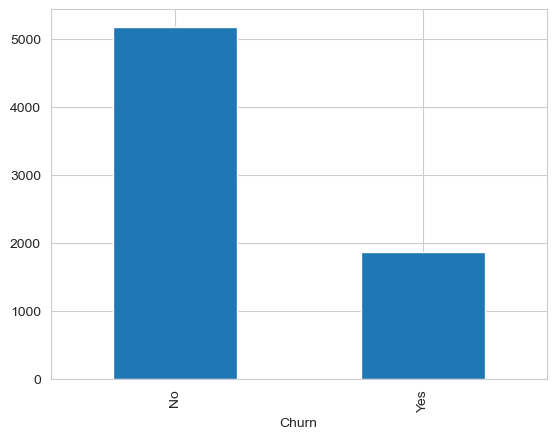

In [67]:
customer_churned = df.groupby('Churn')['customerID'].count().plot(kind = 'bar')
plt.show()

In [68]:
churn_percentage = round(1869/7043,2)
churn_percentage

0.27

In [69]:
customer_churned = df.groupby(['gender','Churn'])['customerID'].size().unstack()
# customer_churned
# plt.show()
customer_churned

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


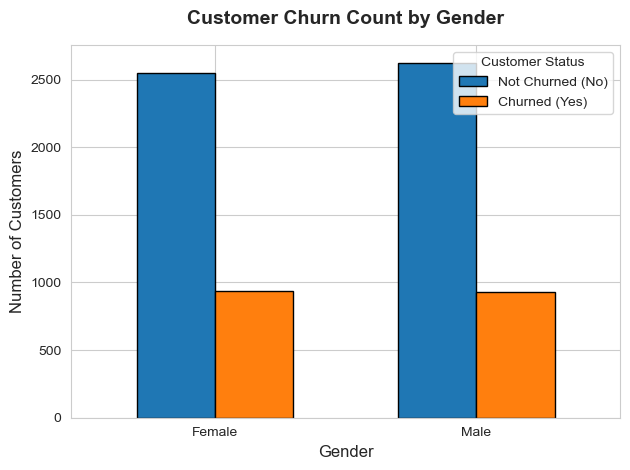

In [70]:
customer_churned.plot(kind='bar', edgecolor='black', width=0.6)


plt.title('Customer Churn Count by Gender', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0) # Keeps 'Male' and 'Female' text horizontal


plt.legend(title='Customer Status', labels=['Not Churned (No)', 'Churned (Yes)'], loc='upper right')

# Add gridlines for readability
# plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [71]:
percent_of_churned = df.groupby('Churn')['customerID'].nunique()
percent_of_churned

Churn
No     5174
Yes    1869
Name: customerID, dtype: int64

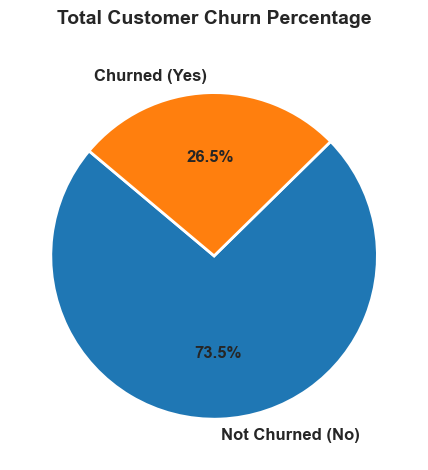

In [72]:
plt.pie(percent_of_churned,
    labels=['Not Churned (No)', 'Churned (Yes)'],
    autopct='%1.1f%%',       # Formats and displays the percentage automatically
    startangle=140,          # Rotates the starting angle for better visual alignment
    shadow=False, 
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} )


# 5. Add title and display
plt.title('Total Customer Churn Percentage', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

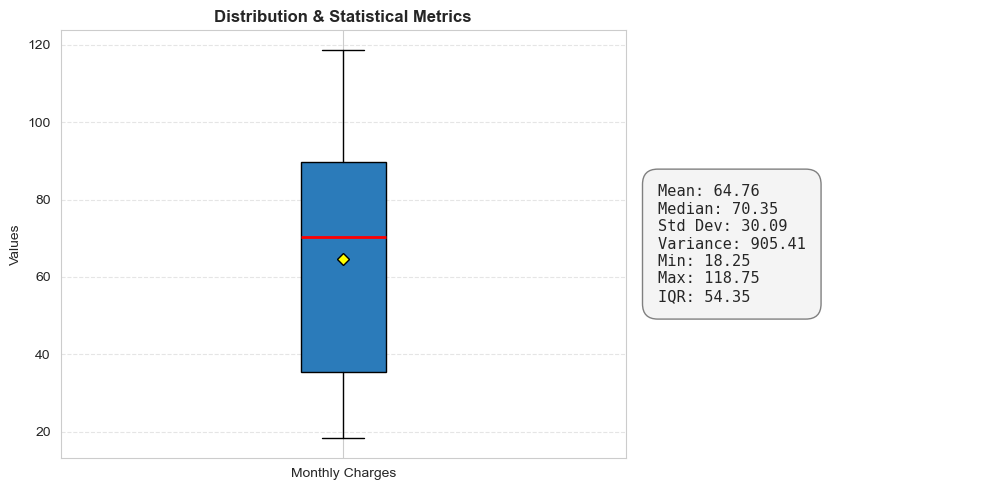

In [73]:
# Calculate all required metrics using Pandas/NumPy
values = df['MonthlyCharges']
q1 = values.quantile(0.25)
q3 = values.quantile(0.75)

metrics = {
    "Mean": values.mean(),
    "Median": values.median(),
    "Std Dev": values.std(),
    "Variance": values.var(),
    "Min": values.min(),
    "Max": values.max(),
    "IQR": q3 - q1
}

# Create the plot layout (1 row, 2 columns to separate plot and text)
fig, (ax_box, ax_text) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [2, 1.2]})

# Plot Box Plot (showMeans draws a point for the mean value)
ax_box.boxplot(values, vert=True, patch_artist=True, showmeans=True,
               boxprops=dict(facecolor='#2b7bba', color='black'),
               meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='yellow'),
               medianprops=dict(color='red', linewidth=2))

ax_box.set_title('Distribution & Statistical Metrics', fontsize=12, fontweight='bold')
ax_box.set_ylabel('Values')
ax_box.set_xticklabels(['Monthly Charges'])
ax_box.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Build and display the text string for metrics
text_str = "\n".join([f"{k}: {v:.2f}" for k, v in metrics.items()])

# Turn off axis lines for the text panel
ax_text.axis('off') 
ax_text.text(0.05, 0.5, text_str, transform=ax_text.transAxes, fontsize=11,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=1', facecolor='#f4f4f4', edgecolor='gray'))

plt.tight_layout()
plt.show()

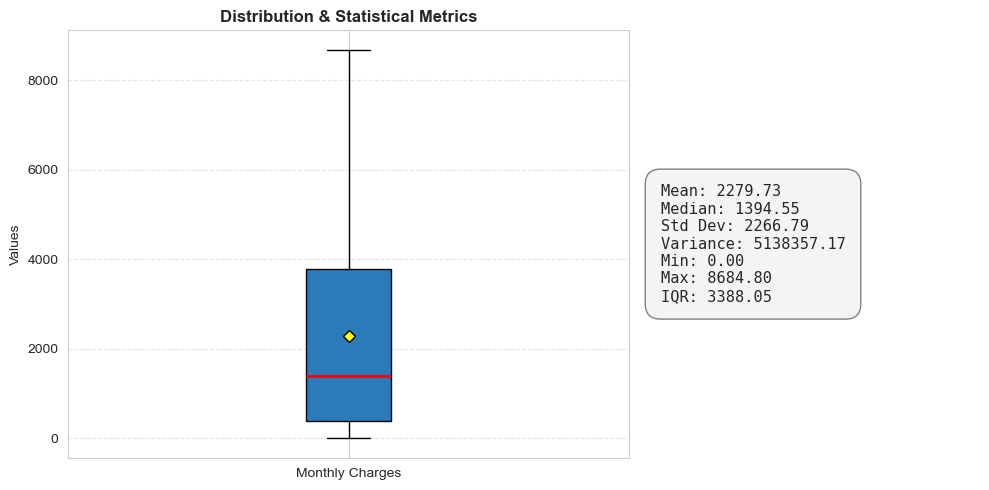

In [74]:
# Calculate all required metrics using Pandas/NumPy
values = df['TotalCharges']
q1 = values.quantile(0.25)
q3 = values.quantile(0.75)

metrics = {
    "Mean": values.mean(),
    "Median": values.median(),
    "Std Dev": values.std(),
    "Variance": values.var(),
    "Min": values.min(),
    "Max": values.max(),
    "IQR": q3 - q1
}

# Create the plot layout (1 row, 2 columns to separate plot and text)
fig, (ax_box, ax_text) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [2, 1.2]})

# Plot Box Plot (showMeans draws a point for the mean value)
ax_box.boxplot(values, vert=True, patch_artist=True, showmeans=True,
               boxprops=dict(facecolor='#2b7bba', color='black'),
               meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='yellow'),
               medianprops=dict(color='red', linewidth=2))

ax_box.set_title('Distribution & Statistical Metrics', fontsize=12, fontweight='bold')
ax_box.set_ylabel('Values')
ax_box.set_xticklabels(['Monthly Charges'])
ax_box.grid(axis='y', linestyle='--', alpha=0.5)

# Build and display the text string for metrics
text_str = "\n".join([f"{k}: {v:.2f}" for k, v in metrics.items()])

# Turn off axis lines for the text panel
ax_text.axis('off') 
ax_text.text(0.05, 0.5, text_str, transform=ax_text.transAxes, fontsize=11,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=1', facecolor='#f4f4f4', edgecolor='gray'))

plt.tight_layout()
plt.show()

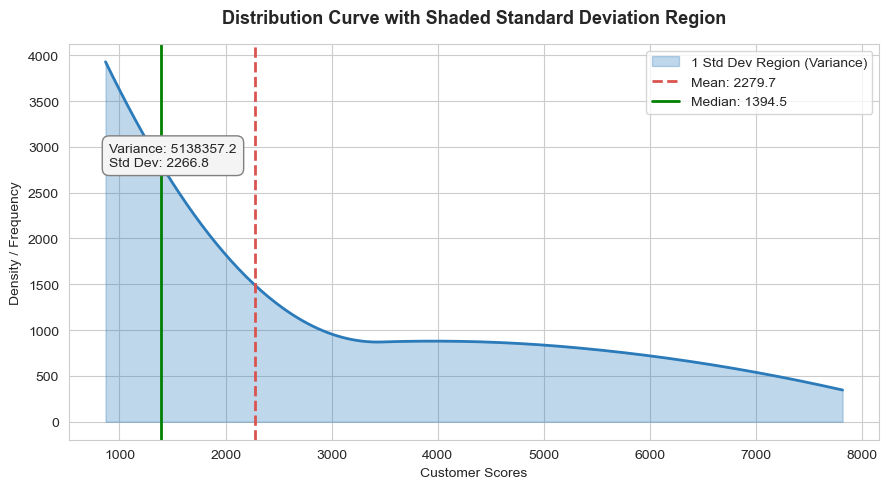

In [75]:
from scipy.interpolate import make_interp_spline

# Calculate the key statistical metrics
mean_val = df['TotalCharges'].mean()
median_val = df['TotalCharges'].median()
std_val = df['TotalCharges'].std()
variance_val = df['TotalCharges'].var()

# Create a smooth distribution curve using a histogram's values
counts, bins = np.histogram(df['TotalCharges'], bins=5)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Interpolate to make the curve perfectly smooth
x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 300)
spline = make_interp_spline(bin_centers, counts, k=2)
y_smooth = spline(x_smooth).clip(min=0) # clip prevents line from dipping below 0

#Plotting
plt.figure(figsize=(9, 5))

# Plot the main smooth curve outline
plt.plot(x_smooth, y_smooth, color='#2b7bba', linewidth=2)



plt.fill_between(
    x_smooth, y_smooth, 
    # where=((x_smooth > lower_std) & (x_smooth < upper_std)), 
    color='#2b7bba', alpha=0.3, label='1 Std Dev Region (Variance)'
)

# Add vertical lines for Mean and Median
plt.axvline(mean_val, color='#d9534f', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')

# Add text metadata card for exact metrics on the chart
text_box_str = f"Variance: {variance_val:.1f}\nStd Dev: {std_val:.1f}"
plt.text(
    0.05, 0.75, text_box_str, transform=plt.gca().transAxes, fontsize=10,
    verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f4f4f4', edgecolor='gray')
)

# Formatting labels, legends, and titles
plt.title('Distribution Curve with Shaded Standard Deviation Region', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Customer Scores')
plt.ylabel('Density / Frequency')
plt.legend(loc='upper right')
# plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

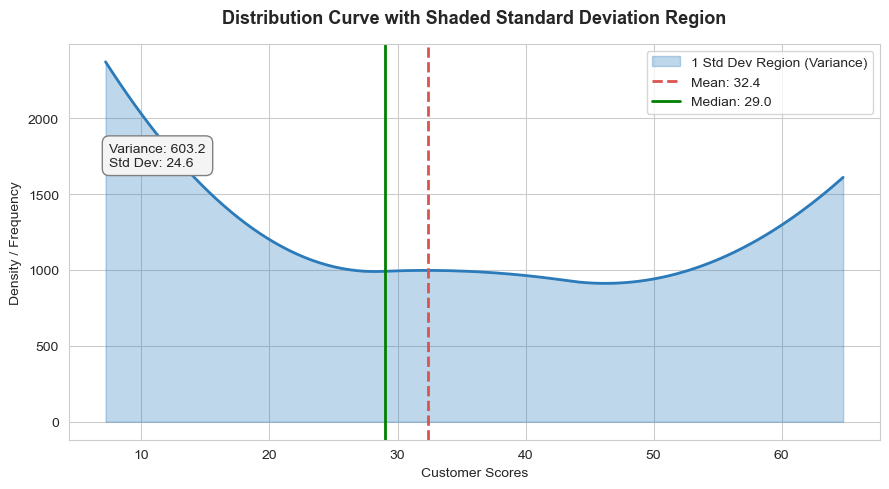

In [76]:
from scipy.interpolate import make_interp_spline

# Calculate the key statistical metrics
mean_val = df['tenure'].mean()
median_val = df['tenure'].median()
std_val = df['tenure'].std()
variance_val = df['tenure'].var()

# Create a smooth distribution curve using a histogram's values
counts, bins = np.histogram(df['tenure'], bins=5)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Interpolate to make the curve perfectly smooth
x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 300)
spline = make_interp_spline(bin_centers, counts, k=2)
y_smooth = spline(x_smooth).clip(min=0) # clip prevents line from dipping below 0

#Plotting
plt.figure(figsize=(9, 5))

# Plot the main smooth curve outline
plt.plot(x_smooth, y_smooth, color='#2b7bba', linewidth=2)



plt.fill_between(
    x_smooth, y_smooth, 
    # where=((x_smooth > lower_std) & (x_smooth < upper_std)), 
    color='#2b7bba', alpha=0.3, label='1 Std Dev Region (Variance)'
)

# Add vertical lines for Mean and Median
plt.axvline(mean_val, color='#d9534f', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')

# Add text metadata card for exact metrics on the chart
text_box_str = f"Variance: {variance_val:.1f}\nStd Dev: {std_val:.1f}"
plt.text(
    0.05, 0.75, text_box_str, transform=plt.gca().transAxes, fontsize=10,
    verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f4f4f4', edgecolor='gray')
)

# Formatting labels, legends, and titles
plt.title('Distribution Curve with Shaded Standard Deviation Region', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Customer Scores')
plt.ylabel('Density / Frequency')
plt.legend(loc='upper right')
# plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

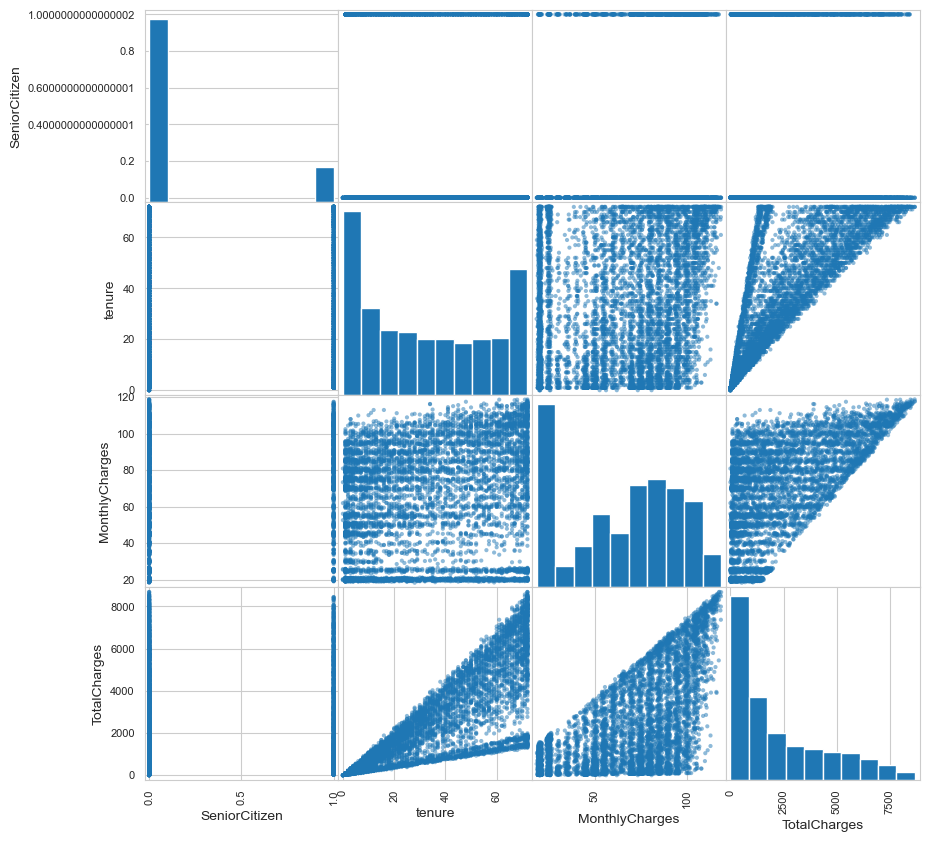

In [77]:
scatter_matrix(df, figsize=(10, 10), diagonal='hist')

# 3. Display the plot
plt.show()

In [78]:
missing_values = df.isnull().sum()

missing_df = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
    .to_frame(name="Missing Count")
)

missing_df["Missing %"] = (
    missing_df["Missing Count"] / len(df) * 100
).round(2)

missing_df


,Missing Count,Missing %


#### Duplicate Values

In [79]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [80]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### Unique Values

In [81]:
unique_counts = pd.DataFrame({
    "Unique Values": df.nunique()
}).sort_values("Unique Values")

unique_counts

,Unique Values
Churn,2
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PaperlessBilling,2
PhoneService,2
Contract,3
StreamingMovies,3
StreamingTV,3


In [82]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [83]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [84]:
dtype_df

,Column,Datatype
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,int64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


In [85]:
dtype_df.loc[dtype_df['Column'] == 'TotalCharges', 'Datatype'] = 'float64'

In [86]:
df['TotalCharges'].dtype

dtype('float64')

In [87]:
Numerical_Cols, Catergorical_Cols = [],[]

for value,key in zip(dtype_df['Datatype'],dtype_df['Column']):
    if value=='object' and key != 'customerID' and key !=  'Churn':
        Catergorical_Cols.append(key)
    elif key != 'customerID' and key !=  'Churn':
        Numerical_Cols.append(key)
print("Numerical Columns: ", Numerical_Cols)
print('Catergorical Columns: ', Catergorical_Cols)

Numerical Columns:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Catergorical Columns:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


#### Data Quality Summary

- Dataset Shape: 7043 Rows X 21 Columns
- Missing Values: 0 
- Duplicate Records: 0
- Constant Columns: 0
- Numeric Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
- Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
- Total Memory Usage:
- Data Quality Issues Observed: Changed the datatype TotalCharges, filled missing values with '0' as basic excecise.

In [88]:
def analyze_numeric_features(df, column):

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Histogram
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30,
        ax=axes[0]
    )

    axes[0].set_title(f"Distribution of {column}")

    # Boxplot
    sns.boxplot(
        x=df[column],
        ax=axes[1]
    )

    axes[1].set_title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

    print(df[column].describe())
    print("Skewness:", df[column].skew())

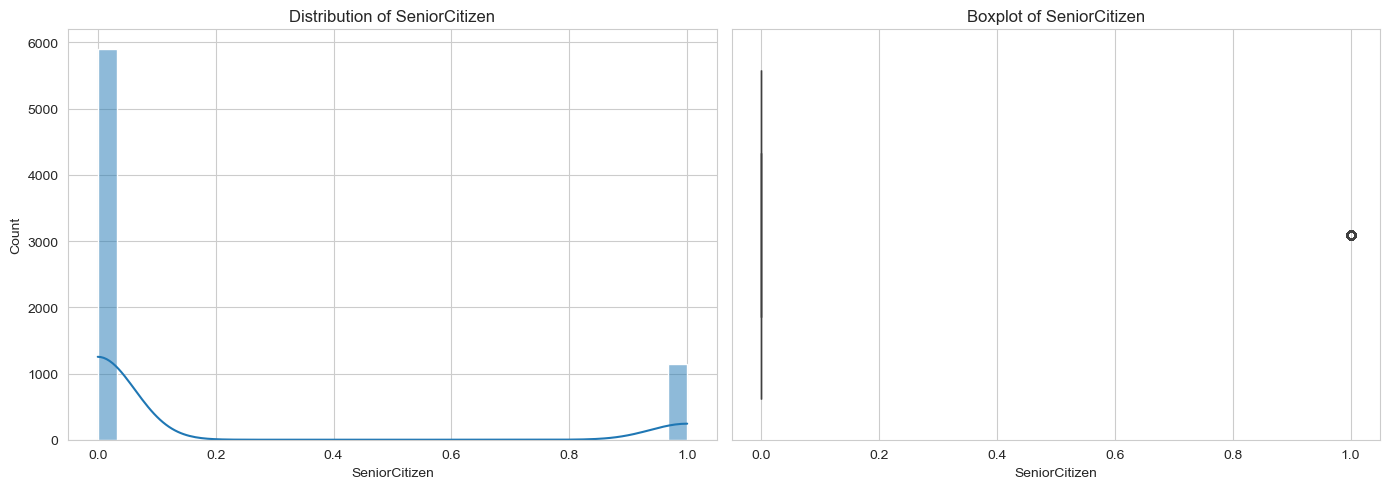

count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64
Skewness: 1.8336327440928564


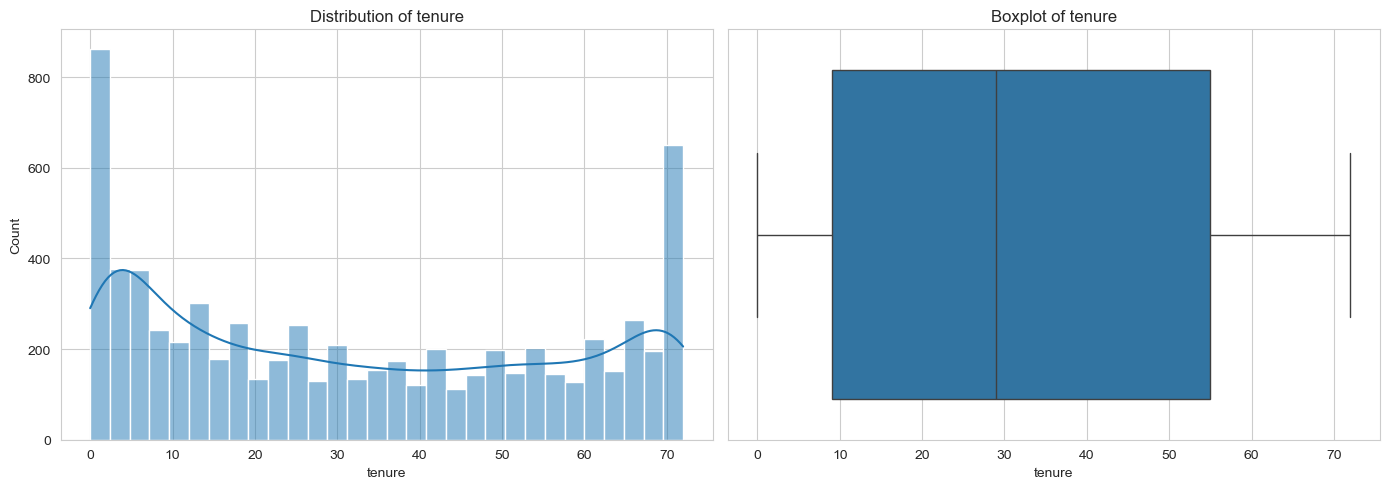

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
Skewness: 0.2395397495619829


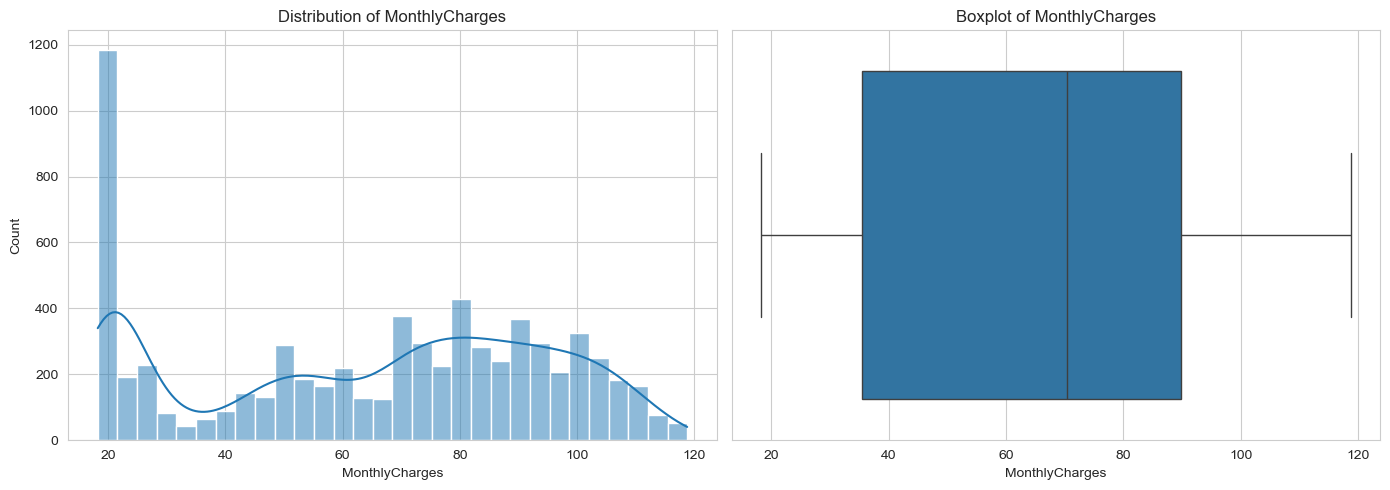

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64
Skewness: -0.22052443394398033


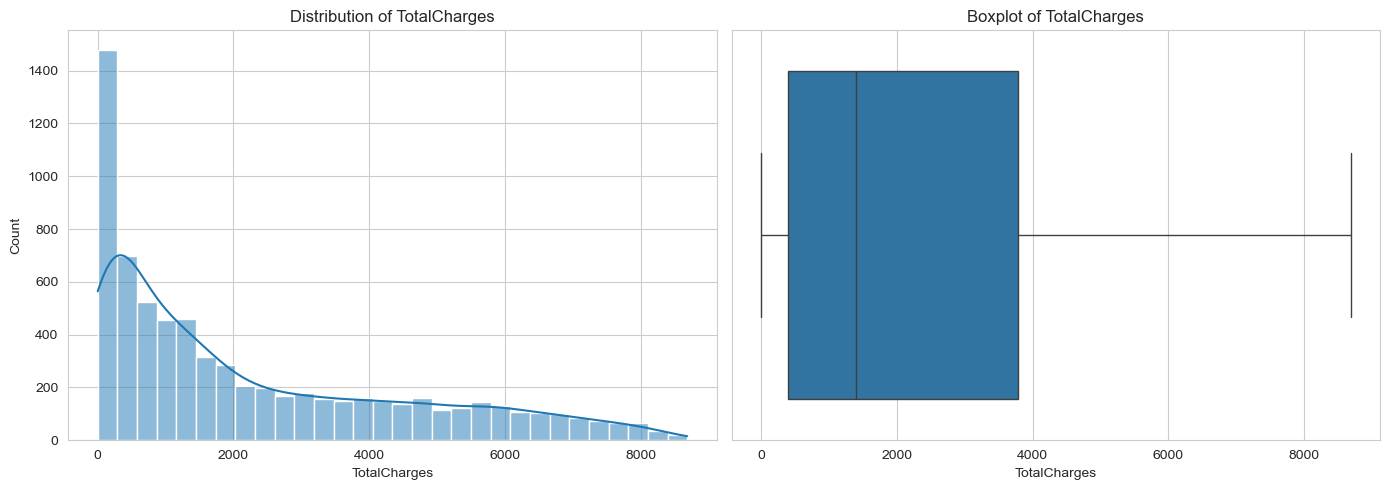

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64
Skewness: 0.963234654832277


In [89]:
for col in Numerical_Cols:
    analyze_numeric_features(df, col)

### BiVariate Analysis

In [90]:
# Lets check the Churn Percentage

(df['Churn'].value_counts(normalize=True)*100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [91]:
New_Numerical_Cols = Numerical_Cols[1:]
New_Numerical_Cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [92]:
New_Categorical_Cols = Catergorical_Cols
New_Categorical_Cols.append('SeniorCitizen')

In [93]:
New_Categorical_Cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [94]:
def analyze_numeric_vs_target(df,column,target = 'Churn'):

    fig,axes = plt.subplots(nrows=1,ncols=3,figsize = (18,5))

    #Boxplot
    sns.boxplot(
        data = df,
        x = target,
        y = column,
        ax = axes[0]
    )

    axes[0].set_title(f"{column} vs {target}")

    #Violinplot
    sns.violinplot(
        data = df,
        x = target,
        y = column,
        ax = axes[1]
    )
    axes[1].set_title(f"{column} Distribution")

    # Histogram
    sns.histplot(
        data = df,
        x = column,
        hue = target,
        kde = True,
        multiple = "stack",
        ax = axes[2]
    )
    axes[2].set_title(f"{column} Histogram")

    plt.tight_layout()
    plt.show()

    print("\nGrouped Statistics")
    print(df.groupby(target)[column].describe())


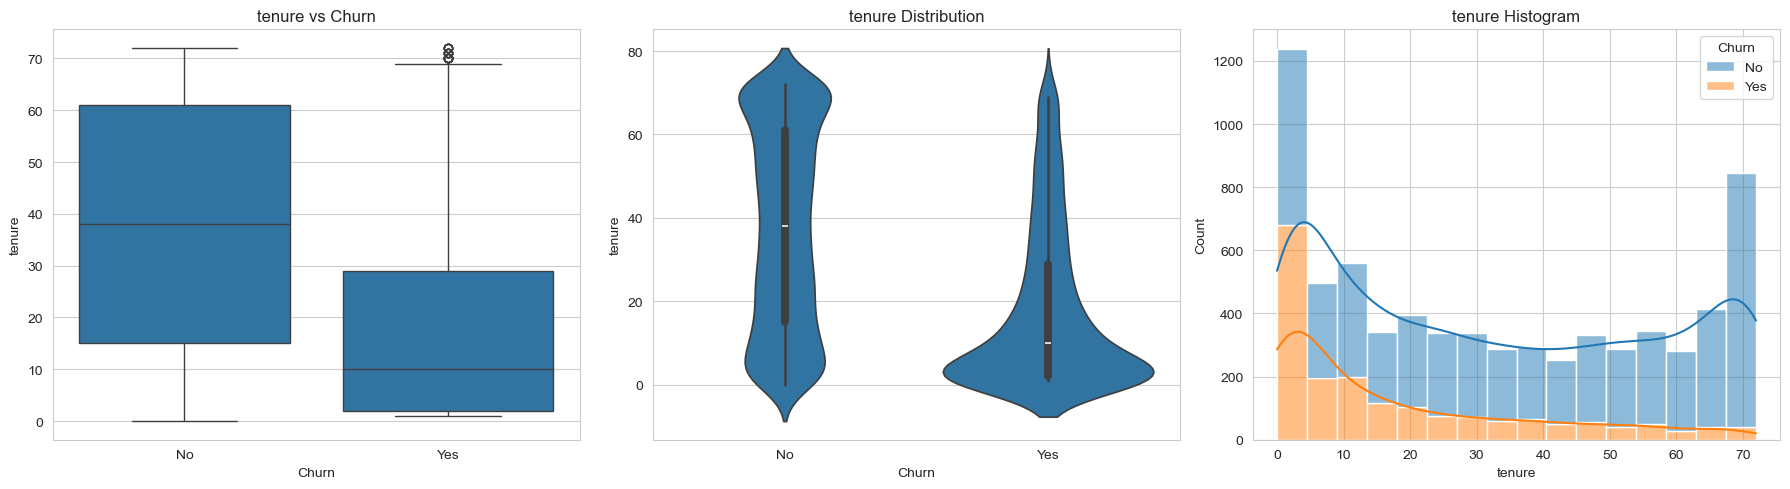


Grouped Statistics
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


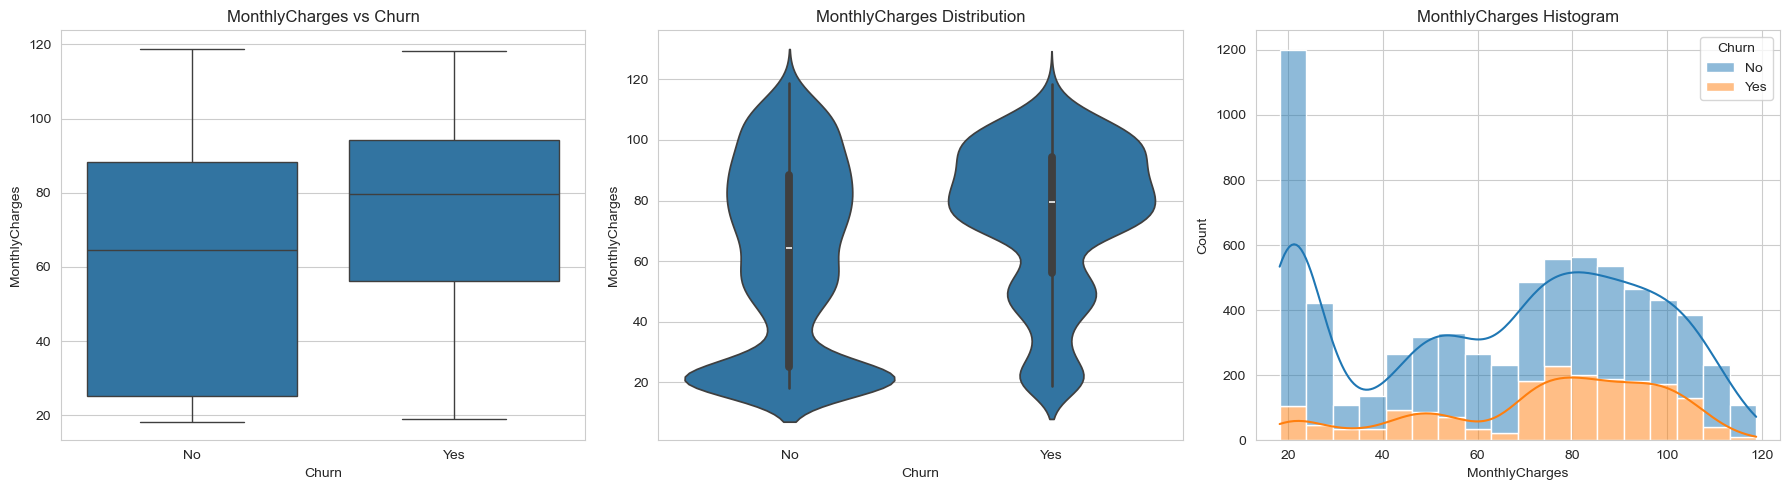


Grouped Statistics
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


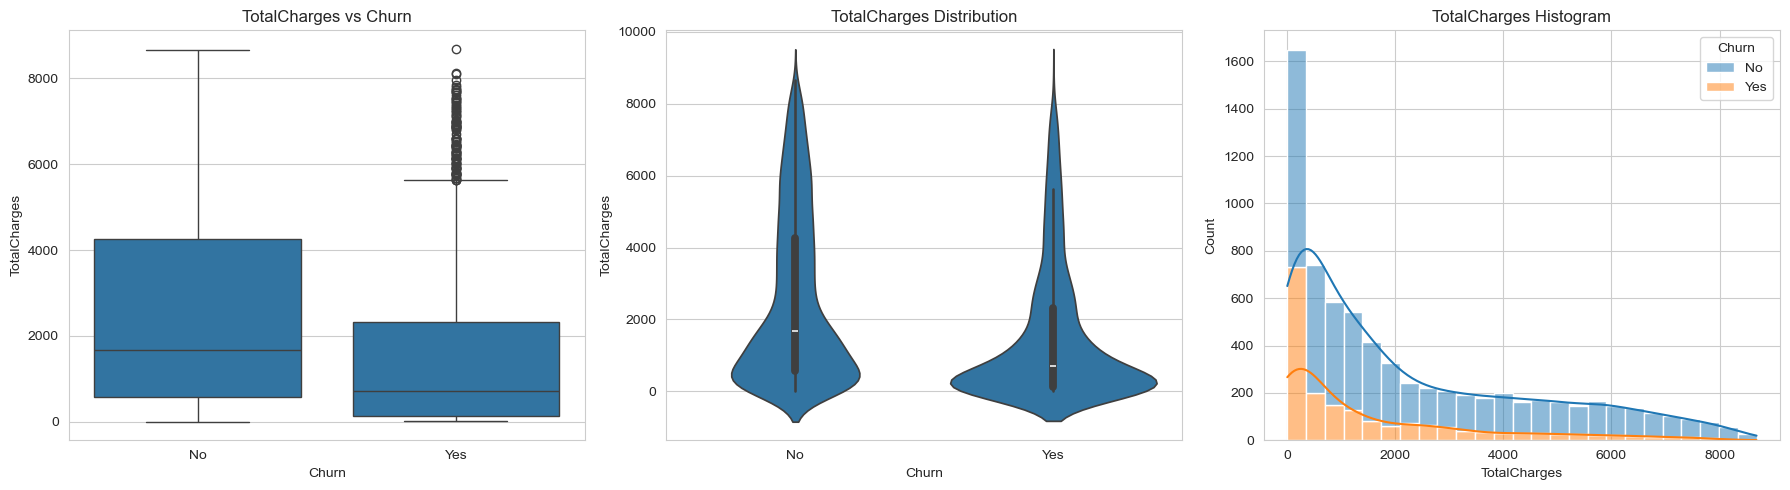


Grouped Statistics
        count         mean          std    min    25%       50%      75%  \
Churn                                                                      
No     5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85   
Yes    1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30   

           max  
Churn           
No     8672.45  
Yes    8684.80  


In [95]:
for col in New_Numerical_Cols:
    analyze_numeric_vs_target(df, col)

In [96]:
def analyze_categorical_vs_target(df, column, target="Churn"):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Countplot
    sns.countplot(
        data=df,
        x=column,
        hue=target,
        ax=axes[0]
    )

    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_title(f"{column} vs {target}")

    # Churn Rate
    churn_rate = (
        pd.crosstab(df[column], df[target], normalize="index") * 100
    )

    churn_rate.plot(
        kind="bar",
        stacked=True,
        ax=axes[1]
    )

    axes[1].set_ylabel("Percentage")
    axes[1].set_title(f"Churn Rate by {column}")

    plt.tight_layout()
    plt.show()

    print("\nCrosstab")
    print(pd.crosstab(df[column], df[target]))

    print("\nPercentage")
    print(churn_rate.round(2))

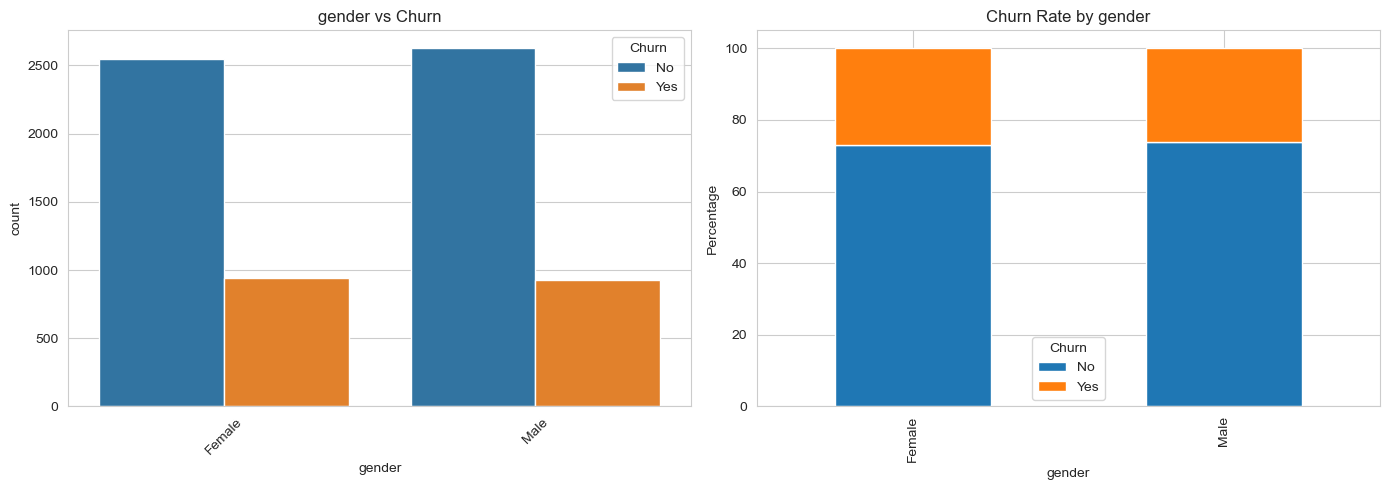


Crosstab
Churn     No  Yes
gender           
Female  2549  939
Male    2625  930

Percentage
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16


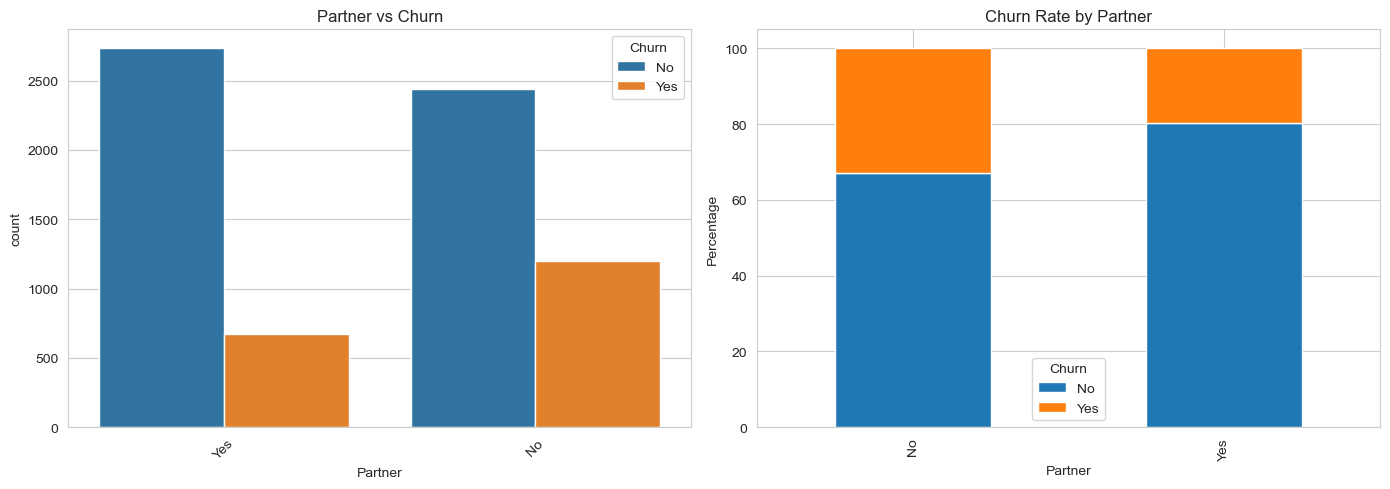


Crosstab
Churn      No   Yes
Partner            
No       2441  1200
Yes      2733   669

Percentage
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66


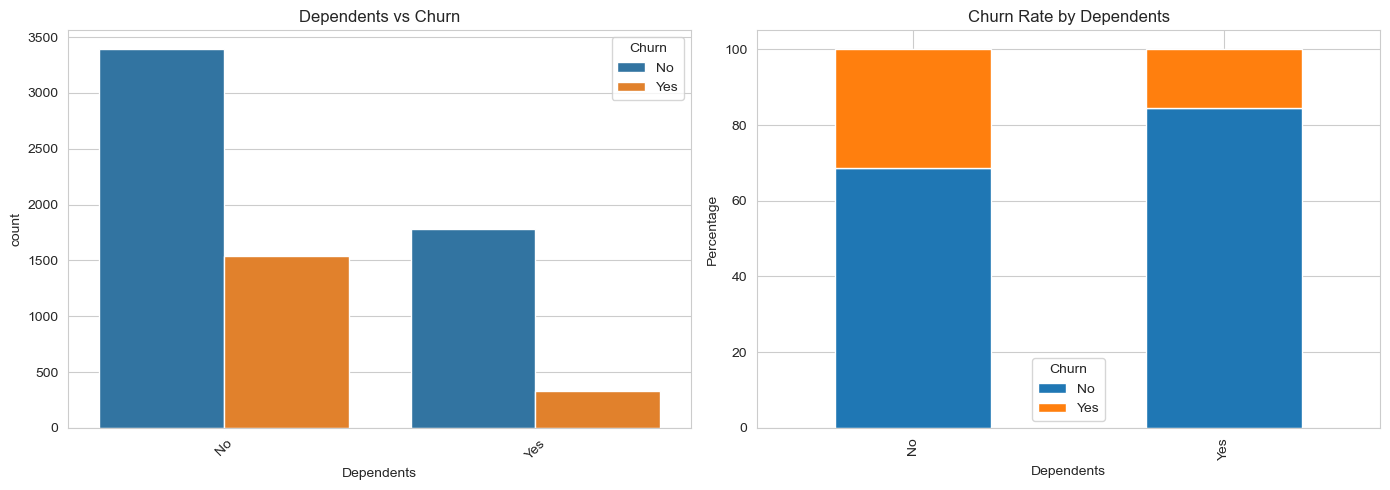


Crosstab
Churn         No   Yes
Dependents            
No          3390  1543
Yes         1784   326

Percentage
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45


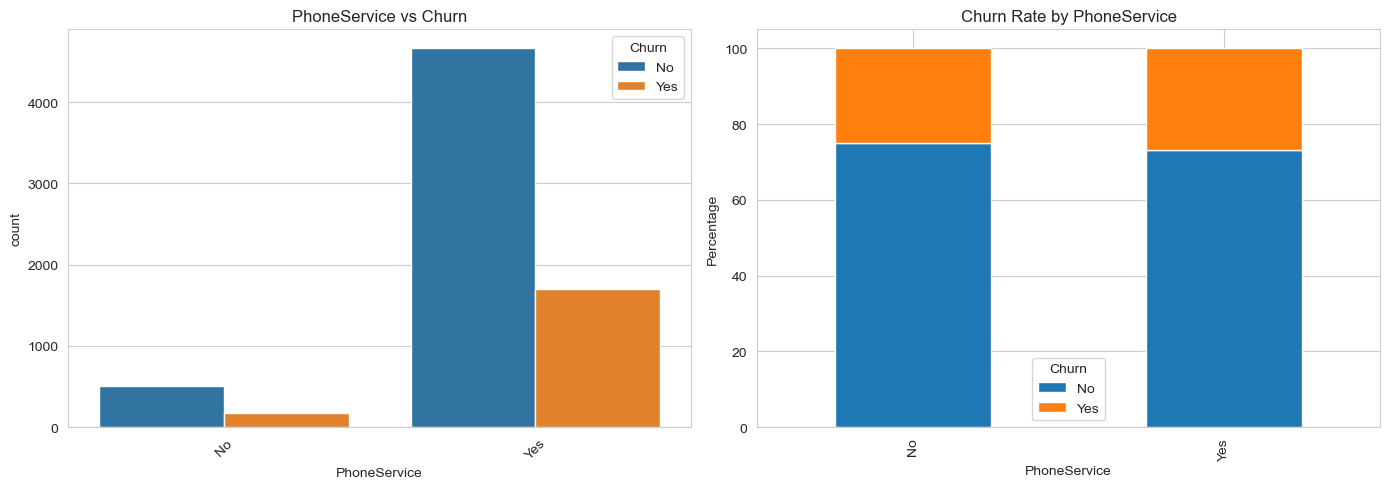


Crosstab
Churn           No   Yes
PhoneService            
No             512   170
Yes           4662  1699

Percentage
Churn            No    Yes
PhoneService              
No            75.07  24.93
Yes           73.29  26.71


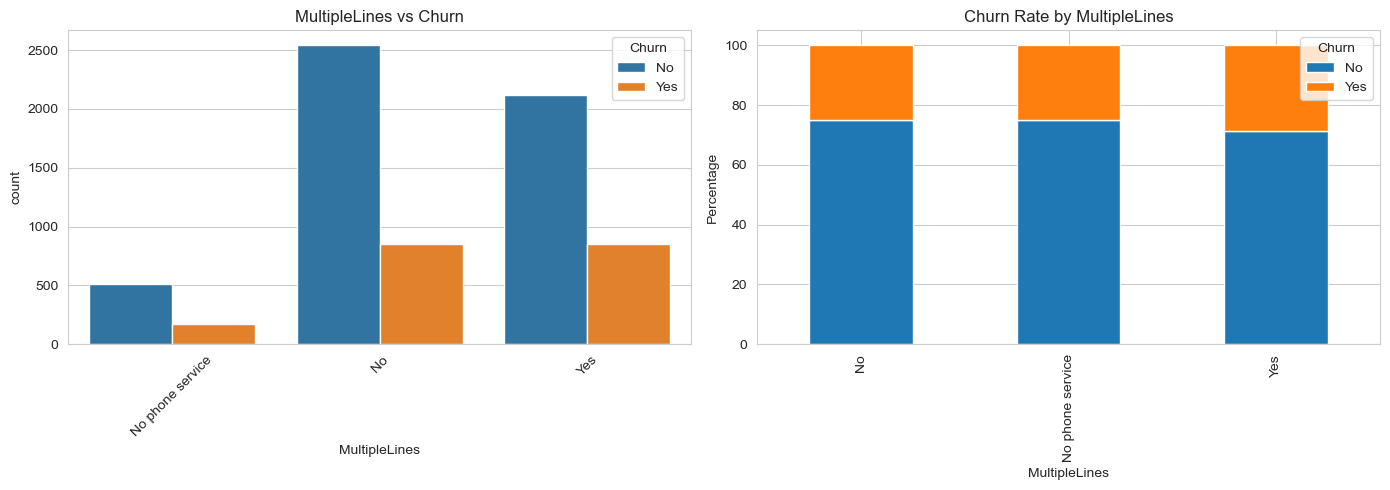


Crosstab
Churn               No  Yes
MultipleLines              
No                2541  849
No phone service   512  170
Yes               2121  850

Percentage
Churn                No    Yes
MultipleLines                 
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61


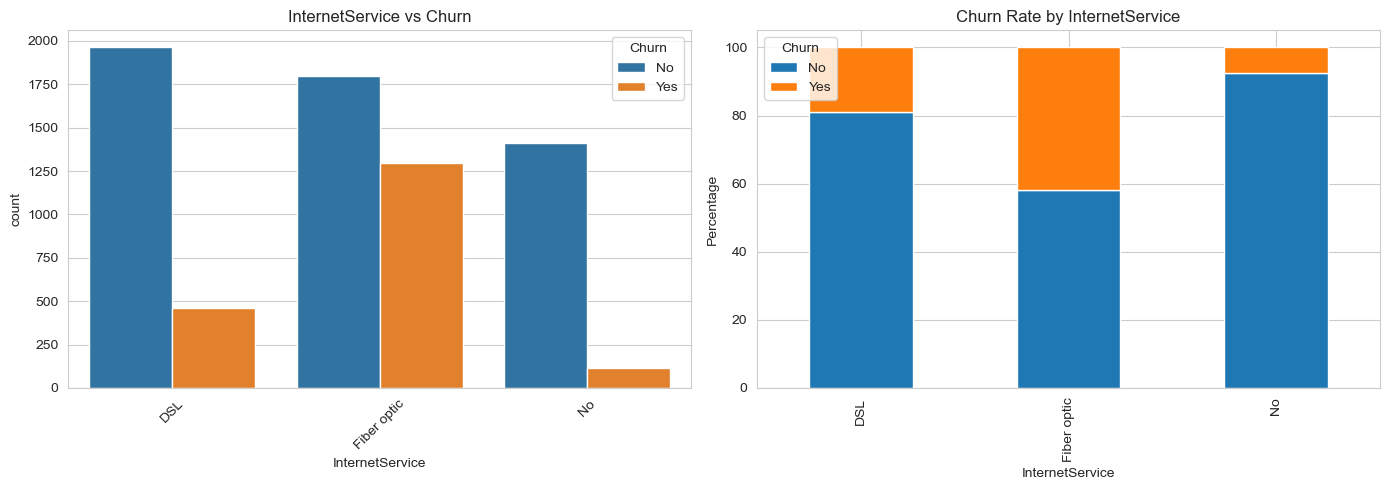


Crosstab
Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113

Percentage
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


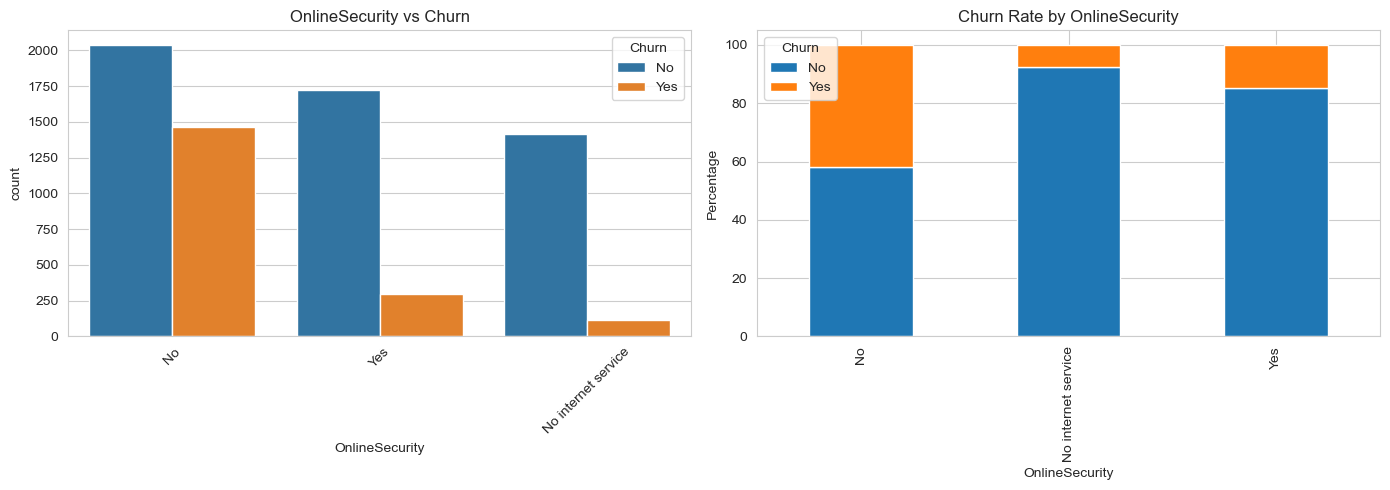


Crosstab
Churn                  No   Yes
OnlineSecurity                 
No                   2037  1461
No internet service  1413   113
Yes                  1724   295

Percentage
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61


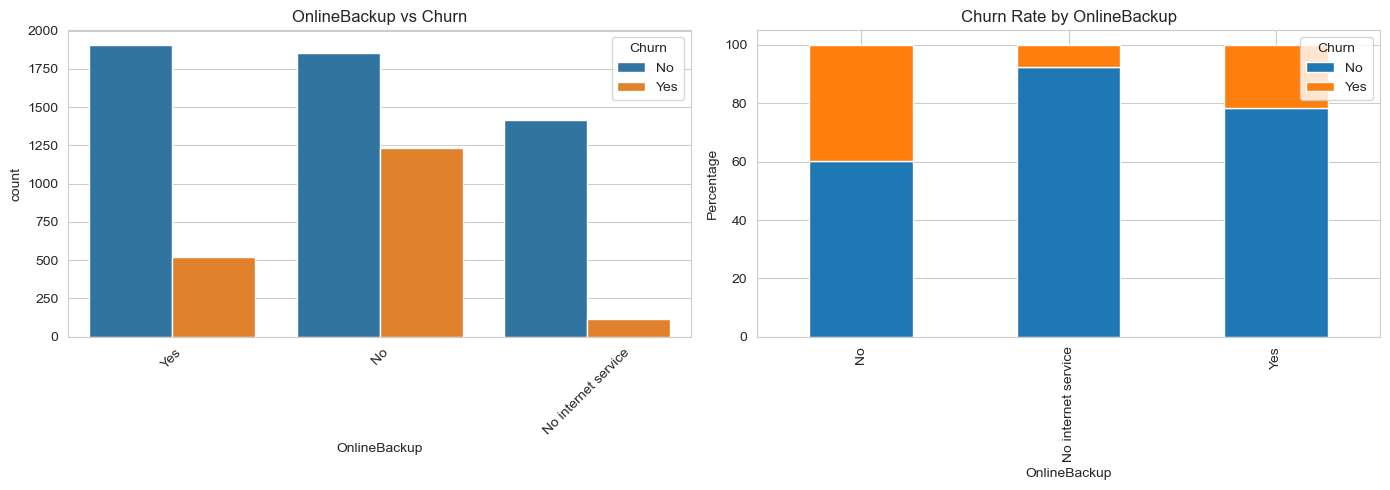


Crosstab
Churn                  No   Yes
OnlineBackup                   
No                   1855  1233
No internet service  1413   113
Yes                  1906   523

Percentage
Churn                   No    Yes
OnlineBackup                     
No                   60.07  39.93
No internet service  92.60   7.40
Yes                  78.47  21.53


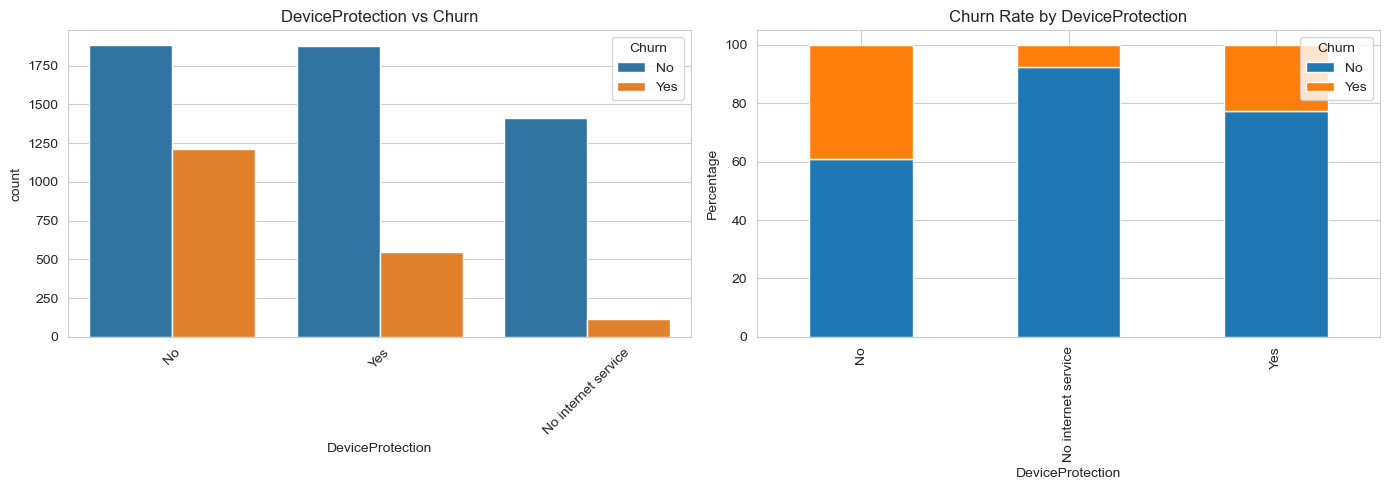


Crosstab
Churn                  No   Yes
DeviceProtection               
No                   1884  1211
No internet service  1413   113
Yes                  1877   545

Percentage
Churn                   No    Yes
DeviceProtection                 
No                   60.87  39.13
No internet service  92.60   7.40
Yes                  77.50  22.50


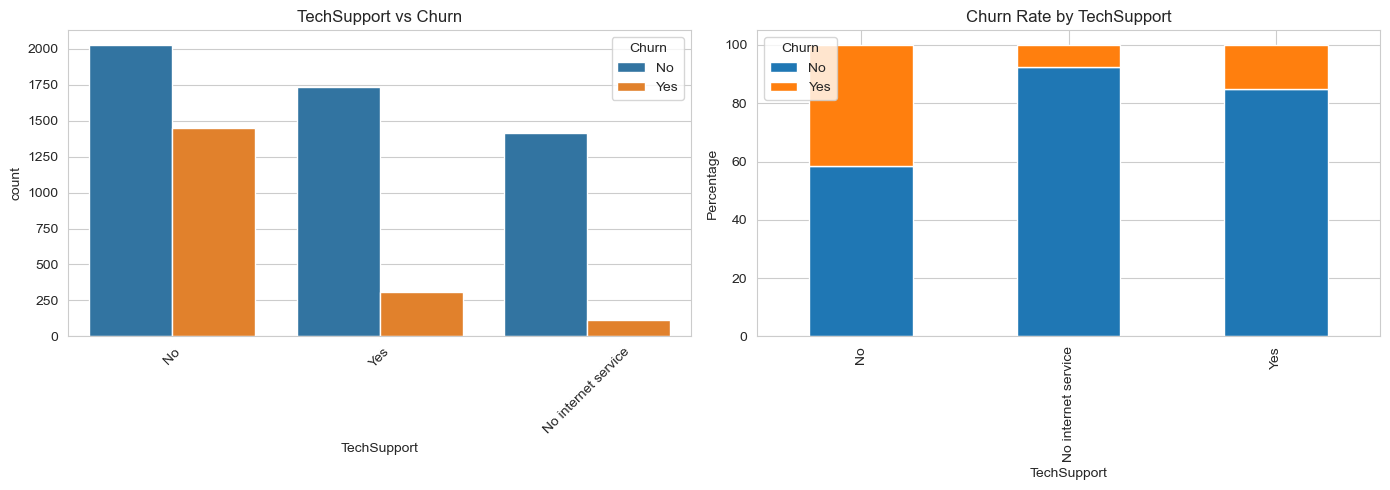


Crosstab
Churn                  No   Yes
TechSupport                    
No                   2027  1446
No internet service  1413   113
Yes                  1734   310

Percentage
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


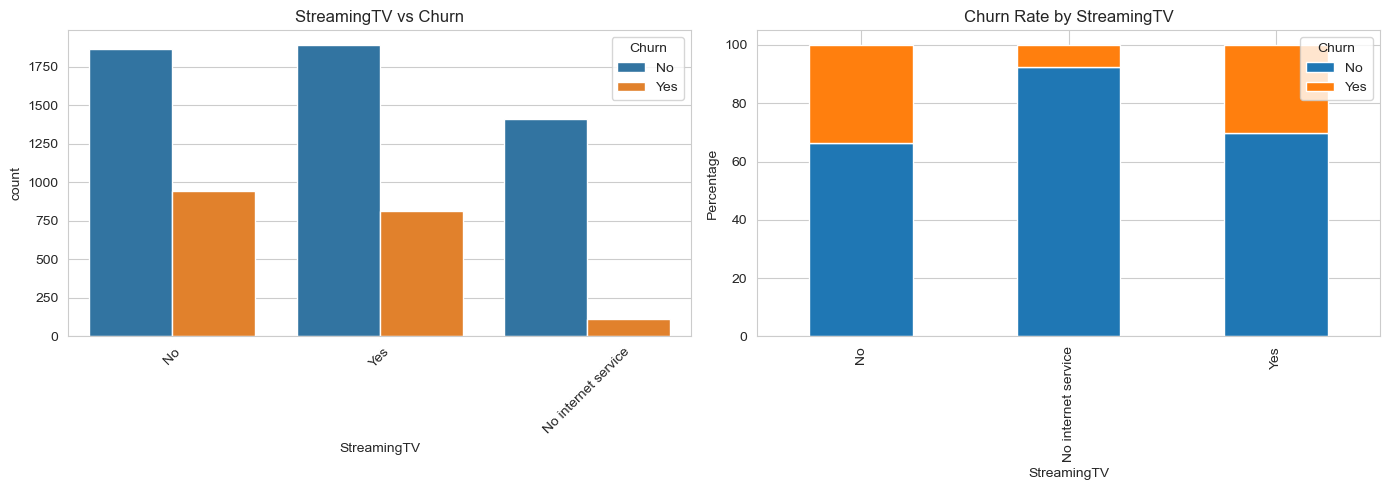


Crosstab
Churn                  No  Yes
StreamingTV                   
No                   1868  942
No internet service  1413  113
Yes                  1893  814

Percentage
Churn                   No    Yes
StreamingTV                      
No                   66.48  33.52
No internet service  92.60   7.40
Yes                  69.93  30.07


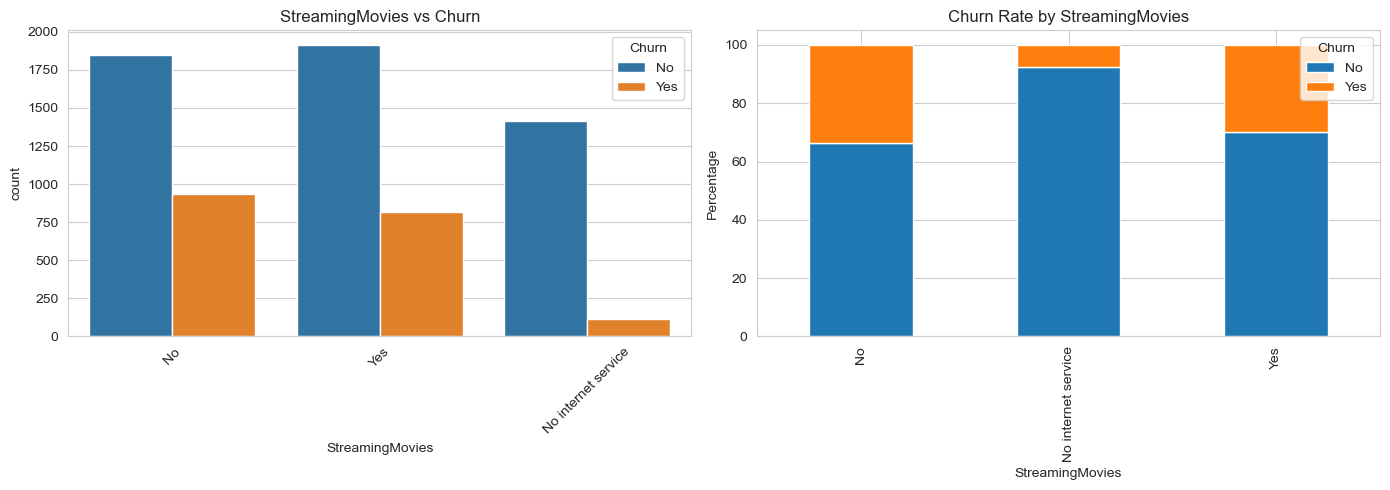


Crosstab
Churn                  No  Yes
StreamingMovies               
No                   1847  938
No internet service  1413  113
Yes                  1914  818

Percentage
Churn                   No    Yes
StreamingMovies                  
No                   66.32  33.68
No internet service  92.60   7.40
Yes                  70.06  29.94


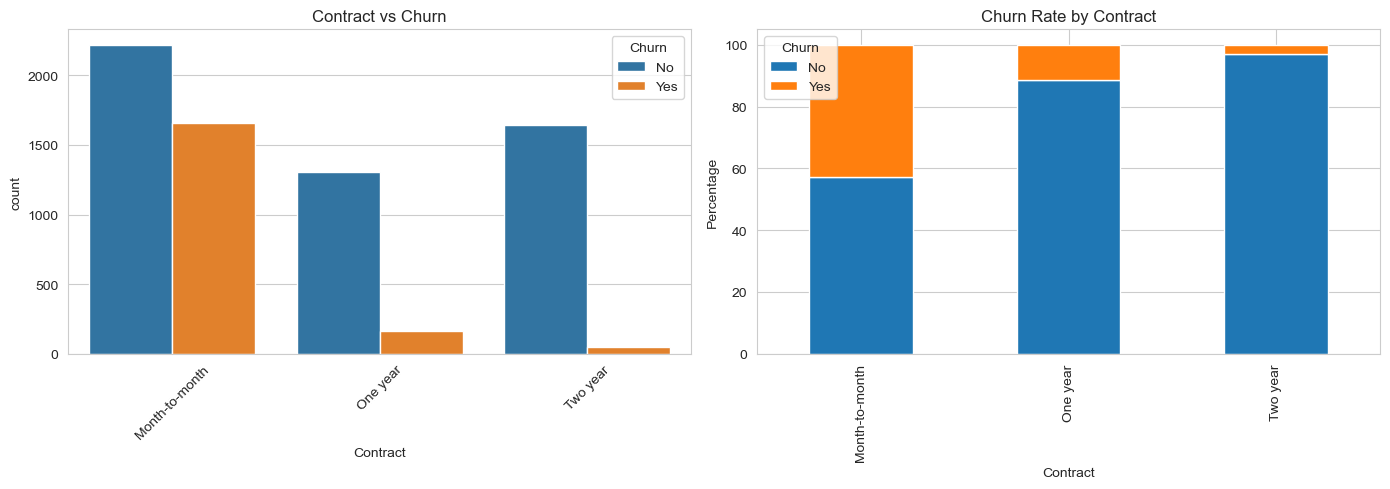


Crosstab
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Percentage
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


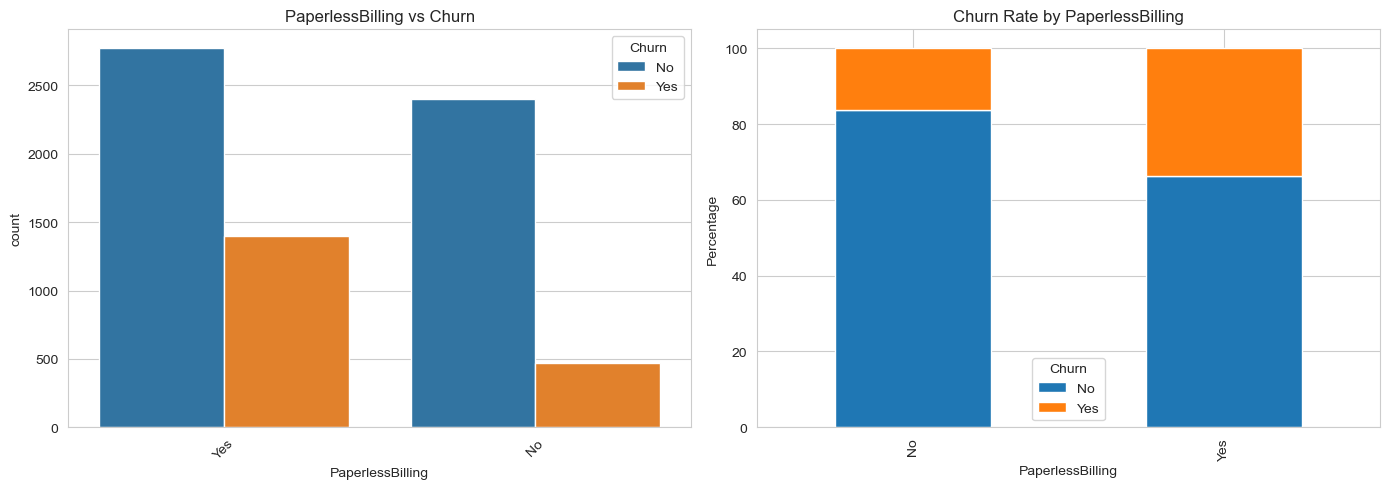


Crosstab
Churn               No   Yes
PaperlessBilling            
No                2403   469
Yes               2771  1400

Percentage
Churn                No    Yes
PaperlessBilling              
No                83.67  16.33
Yes               66.43  33.57


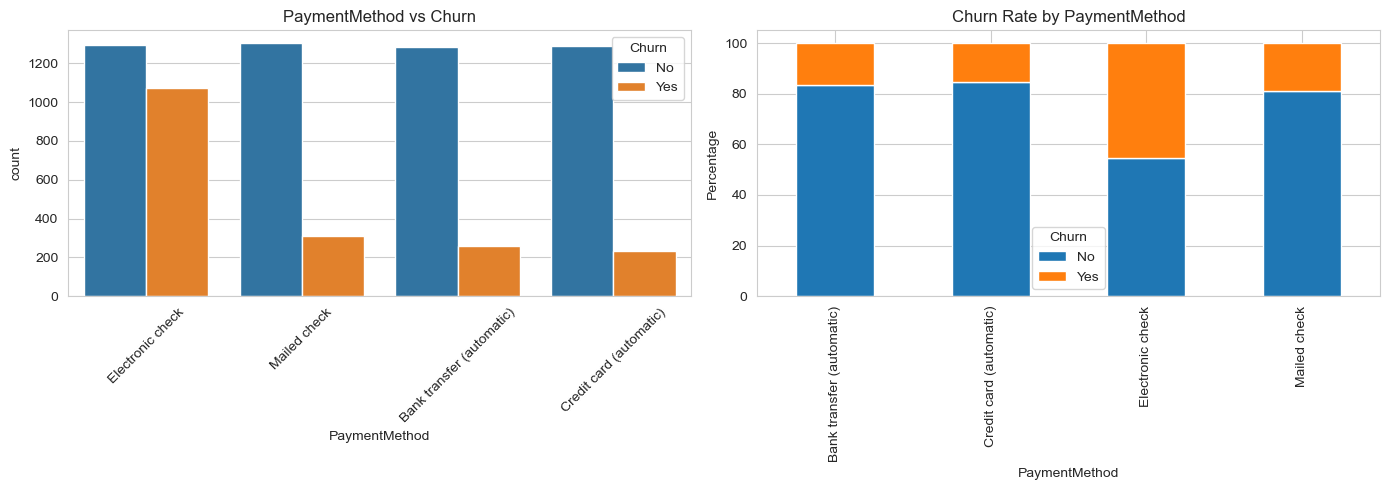


Crosstab
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308

Percentage
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


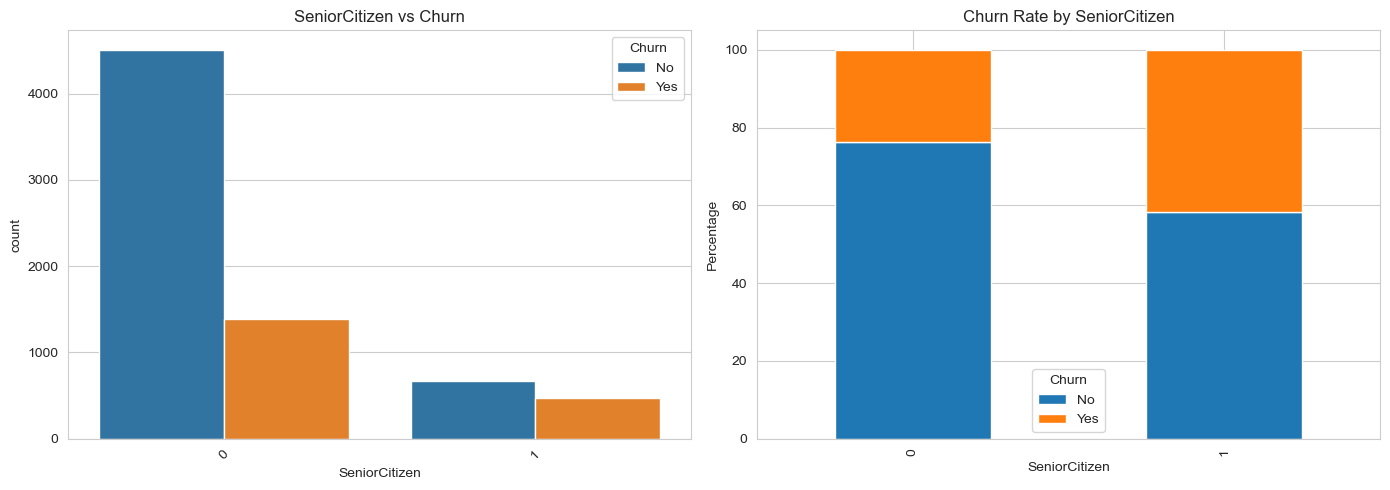


Crosstab
Churn            No   Yes
SeniorCitizen            
0              4508  1393
1               666   476

Percentage
Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68


In [97]:
for col in New_Categorical_Cols:
    analyze_categorical_vs_target(df, col)

##### Statistical Validation using Chi-Square and T-tests

In [98]:
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [99]:
def chi_square_test(df, feature, target="Churn"):

    contingency_table = pd.crosstab(df[feature], df[target])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    return {
        "Feature": feature,
        "Chi2 Statistic": round(chi2, 2),
        "P-Value": round(p, 5),
        "Significant": "Yes" if p < 0.05 else "No"
    }

In [100]:
results = []

for col in New_Categorical_Cols:
    results.append(chi_square_test(df, col))

chi_square_results = pd.DataFrame(results)

chi_square_results.sort_values("P-Value")

,Feature,Chi2 Statistic,P-Value,Significant
1,Partner,158.73,0.00000,Yes
2,Dependents,189.13,0.00000,Yes
5,InternetService,732.31,0.00000,Yes
6,OnlineSecurity,850.00,0.00000,Yes
7,OnlineBackup,601.81,0.00000,Yes
8,DeviceProtection,558.42,0.00000,Yes
9,TechSupport,828.20,0.00000,Yes
10,StreamingTV,374.20,0.00000,Yes
11,StreamingMovies,375.66,0.00000,Yes
12,Contract,1184.60,0.00000,Yes


##### Lets the make Multi Variate Analysis

Multivariate Analysis
</br>
├── Step 1: Correlation Analysis
</br>
├── Step 2: Correlation Heatmap
</br>
├── Step 3: Pair Plot (Selected Features)
</br>
├── Step 4: Multicollinearity Check (VIF)
</br>
├── Step 5: Feature Relationship Summary

In [101]:
corr_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

corr_matrix = df[corr_cols].corr()

corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


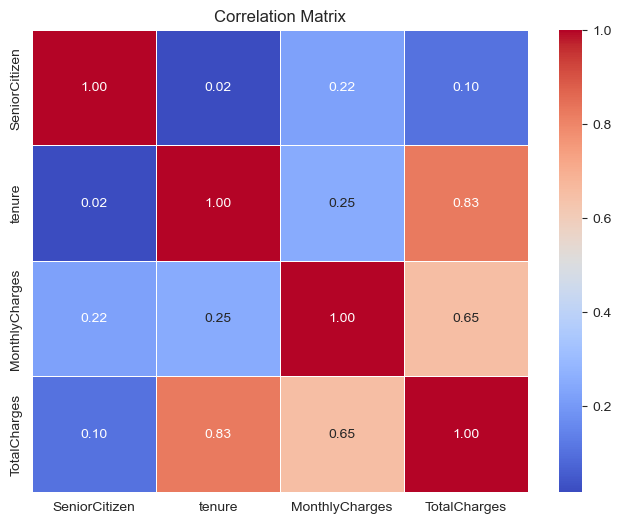

In [102]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

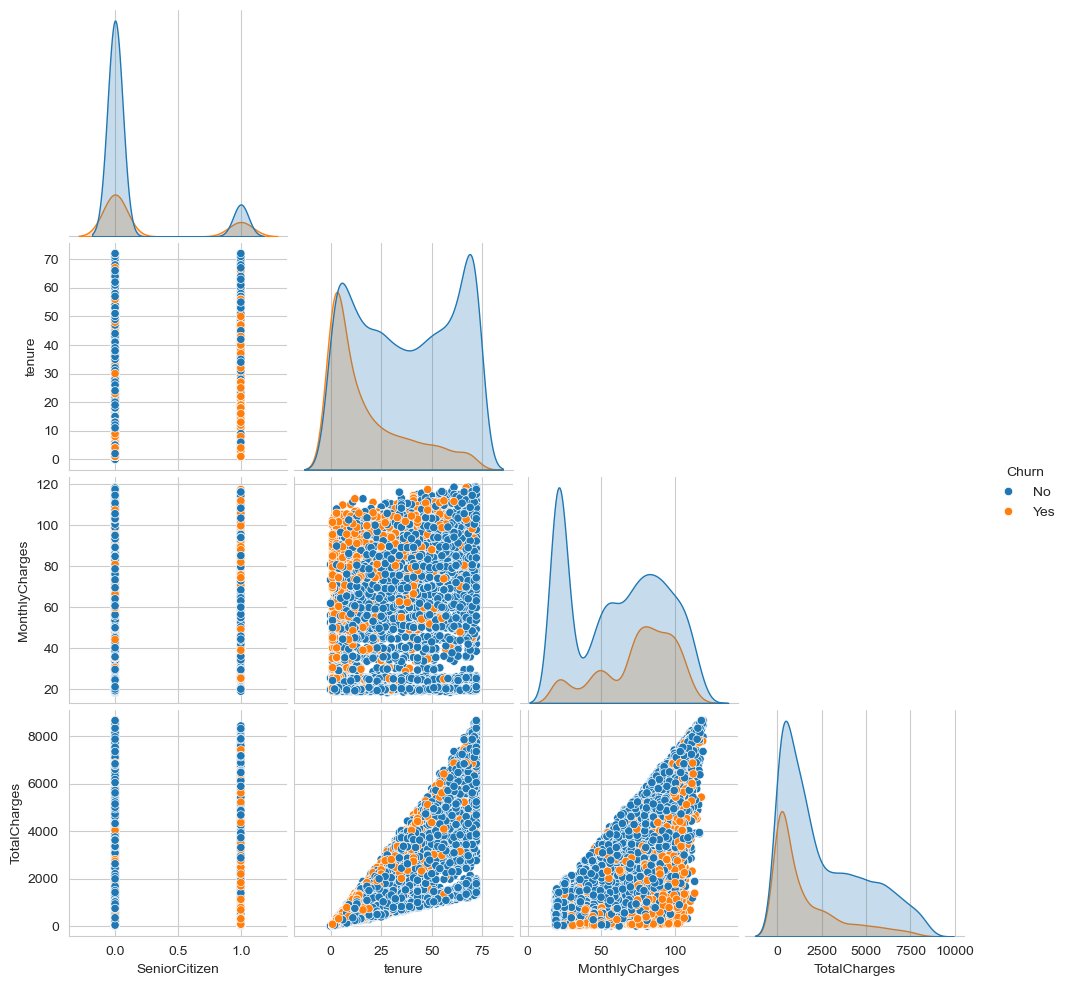

In [103]:
sns.pairplot(
    df[corr_cols + ["Churn"]],
    hue="Churn",
    corner=True
)

plt.show()

In [105]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[corr_cols].copy()

vif_df = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif_df

,Feature,VIF
0,SeniorCitizen,1.257276
1,tenure,6.332627
2,MonthlyCharges,3.694794
3,TotalCharges,8.080935


### Feature Engineering

In [106]:
df = df.drop(columns = ['customerID'])

X = df.drop(columns = ['Churn'])
y = df['Churn']

print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [108]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]


print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [110]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)


print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 40)
(1409, 40)


In [111]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__tenure' 'num__MonthlyCharges' 'num__TotalCharges'
 'cat__gender_Male' 'cat__SeniorCitizen_1' 'cat__Partner_Yes'
 'cat__Dependents_Yes' 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No' 'cat__StreamingMovies_No internet service'
 'cat__StreamingMovies_Yes' 'cat__Contract_Month-to-month'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__PaperlessBillin

In [116]:
import joblib

joblib.dump(preprocessor, r"C:\Users\PRAVEEN\Project_2\Customer_Churn\artifacts\artifactspreprocessor.pkl")

['C:\\Users\\PRAVEEN\\Project_2\\Customer_Churn\\artifacts\\artifactspreprocessor.pkl']